In [ ]:
from sklearn import datasets
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import math


In [ ]:
mean1 = [ -2, 0]
mean2 = [2,0]
#mean3 = [0,2 * math.sqrt(3) ]



In [ ]:
cov = [[0.5,0], [0,0.5]]

In [ ]:
A1 = np.random.multivariate_normal(mean1, cov ,20)  #normal
A2 = np.random.multivariate_normal(mean2, cov ,20) 
A3 = np.random.multivariate_normal(mean1, cov ,20) 

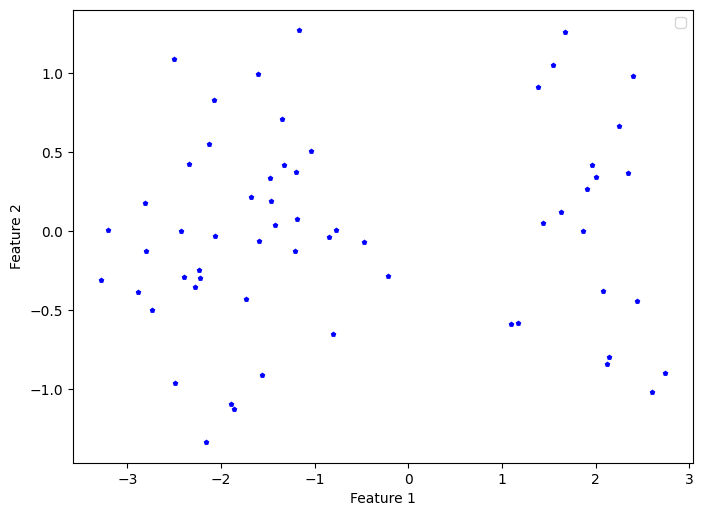

In [ ]:
fig = plt.figure(figsize=(8,6), dpi = 100)
plt.plot(A1[:, 0], A1[:, 1], 'bp', markersize = 3)
plt.plot(A2[:, 0], A2[:, 1], 'bp', markersize = 3)
plt.plot(A3[:, 0], A3[:, 1], 'bp', markersize = 3)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

In [ ]:
df_A1 = pd.DataFrame(A1, columns = ['f1', 'f2'])
df_A2 = pd.DataFrame(A2, columns = ['f1', 'f2'])
df_A3 = pd.DataFrame(A3, columns = ['f1', 'f2'])


df = pd.concat([df_A1, df_A2, df_A3], axis = 0, ignore_index = True)


In [ ]:
df


,f1,f2
0,-2.275330,-0.355312
1,-0.473467,-0.068806
2,-0.220241,-0.284057
3,-2.061764,-0.030323
4,-2.230568,-0.244313
5,-2.339534,0.422784
6,-1.863651,-1.124678
7,-2.427142,-0.000550
8,-1.480636,0.335489
9,-0.841885,-0.039686


In [ ]:
X = df.to_numpy(dtype = None, copy = False)

In [ ]:
dist_mat = np.zeros((len(X),len(X)))

In [ ]:
for i in range(1, len(dist_mat[0])):
  for j in range(i):
    for k in range(len(dist_mat[0])):
      if k == i or k == j:
        continue
        print(i)
      dist_mat[i][j] += abs(np.linalg.norm(X[i] - X[k]) - np.linalg.norm(X[j] - X[k]))
    dist_mat[i][j] /= (len(dist_mat[0])-2)

In [ ]:
dist_mat

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [1.23991246, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [1.38366366, 0.24370643, 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.09564992, 1.29516166, 1.43117561, ..., 0.        , 0.        ,
        0.        ],
       [0.67477326, 0.79831182, 0.97100561, ..., 0.72503097, 0.        ,
        0.        ],
       [0.86274389, 0.60995372, 0.83867893, ..., 0.92617004, 0.49633665,
        0.        ]])

In [ ]:
def ret_min(a, b): # Returns minimum of a and b
  if a>b:
    return b
  return a

In [ ]:
def clustering(matrix, hierarchy):
  
  # Base case
  if len(matrix) == 2:
    min_i = 0
    min_j = 1
    hierarchy = hierarchy[:min_i] + [hierarchy[min_i], hierarchy[min_j]] + hierarchy[min_j+1:]  
    return hierarchy

  min = matrix[1][0] #initializing minimum distance
  min_i, min_j = 1, 0

  for i in range(1, len(matrix[0])):
    for j in range(i):
      if i>j and ((i-j) == 1):
        if matrix[i][j]<min:
          min = matrix[i][j]
          min_i = i
          min_j = j
  
  '''
  b = np.where(matrix == 0.0, max, matrix)
  min = np.min(b)
  min_i, min_j = np.where(b == np.min(b))
  min_i, min_j = min_i[0], min_j[0]
  
  '''
  
  
  # Swapping min_i, min_j in order to maintain min_i < min_j
  if min_i > min_j:
    a = min_i
    min_i = min_j
    min_j = a
  
  
  hierarchy = hierarchy[:min_i] + [[hierarchy[min_i], hierarchy[min_j]]] + hierarchy[min_j+1:]

  dist_mat = np.copy(matrix) # Copying the original matrix so that original matrix is not affected by further operations
  dist_mat = np.delete(dist_mat, (min_j), axis=0) # Deleting  min_j row
  dist_mat = np.delete(dist_mat, (min_j), axis=1) # Deleting  min_j column

  """
  # Copying the remaining matrix to new distance matrix for recursion
  dist_mat_2 = np.zeros((len(matrix)-1, len(matrix)-1))
  for i in range(len(matrix)-2):
    for j in range(len(matrix)-2):
      dist_mat_2[i][j] = dist_mat[i][j]
  """

  # Deleting dist_mat in order to save space
  #dist_mat = np.delete(dist_mat, [i for i in range(len(dist_mat))], 0)

  dist_min_i = [] # List of distances from point min_i to all other points except min_j
  dist_min_j = [] # List of distances from point min_j to all other points except min_i

  for i in range(len(matrix)):
    if i<min_i:
      dist_min_i += [matrix[min_i][i]]
      dist_min_j += [matrix[min_j][i]]
    elif i == min_i or i == min_j:
      continue
    elif i<min_j:
      dist_min_i += [matrix[i][min_i]]
      dist_min_j += [matrix[min_j][i]]
    else:
      dist_min_i += [matrix[i][min_i]]
      dist_min_j += [matrix[i][min_j]]
  
  # Filling the last row of new distance matrix
  for i in range(len(dist_min_i)):
    if i < min_i:
      dist_mat[min_i][i] = ret_min(dist_min_i[i], dist_min_j[i])
    else:
      dist_mat[i+1][min_i] = ret_min(dist_min_i[i], dist_min_j[i])
  
  dist_min_i = []
  dist_min_j = []

  if (len(hierarchy) == 3):
    return hierarchy
  '''
  t += 1
  if t == 5:
    return hierarchy  
  '''
  hierarchy = clustering(dist_mat, hierarchy) # The recusion call

  return hierarchy

In [ ]:
from collections import Iterable

def flatten(lis):
     for item in lis:
         if isinstance(item, Iterable) and not isinstance(item, str):
             for x in flatten(item):
                 yield x
         else:        
             yield item

In [ ]:
hier1 = [[i] for i in range(len(dist_mat))]
cluster = clustering(dist_mat, hier1)
print(hier1)

[[0], [1], [2], [3], [4], [5], [6], [7], [8], [9], [10], [11], [12], [13], [14], [15], [16], [17], [18], [19], [20], [21], [22], [23], [24], [25], [26], [27], [28], [29], [30], [31], [32], [33], [34], [35], [36], [37], [38], [39], [40], [41], [42], [43], [44], [45], [46], [47], [48], [49], [50], [51], [52], [53], [54], [55], [56], [57], [58], [59]]


In [ ]:
print(cluster[0])
print(cluster[1])
print(cluster[2])

[[0], [[[1], [2]], [[[[3], [4]], [5]], [[6], [[7], [[8], [[9], [[[10], [[[11], [[12], [13]]], [14]]], [[[[[15], [16]], [17]], [18]], [19]]]]]]]]]]
[[[20], [[[[[[[[21], [22]], [23]], [24]], [25]], [[[26], [27]], [[28], [[29], [[30], [[[31], [[32], [33]]], [34]]]]]]], [35]], [[36], [[37], [38]]]]], [39]]
[[[[[[[[[[[40], [[[41], [42]], [[[43], [44]], [[45], [[46], [[47], [[48], [49]]]]]]]], [50]], [[51], [52]]], [53]], [54]], [55]], [56]], [57]], [58]], [59]]


In [ ]:
cluster_1 = sorted(list(flatten(cluster[1])))
cluster_2 = sorted(list(flatten(cluster[0])))
cluster_3 = sorted(list(flatten(cluster[2])))

In [ ]:
print(cluster_1)
print(cluster_2)
print(cluster_3)

[20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
[40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59]
